In [26]:
from _bootstrap import setup

setup()

PosixPath('/home/arieltr/Projects/master-thesis/source/ai-agent')

In [27]:
import numpy as np
import open3d as o3d

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

from geometry.voxelizer import MeshSliceRenderer

In [28]:
mesh = o3d.io.read_triangle_mesh(o3d.data.KnotMesh().path)

mesh.remove_unreferenced_vertices()
mesh.remove_degenerate_triangles()
mesh.remove_duplicated_triangles()
mesh.remove_duplicated_vertices()

mesh_vertices = np.asarray(mesh.vertices)
mesh_triangles = np.asarray(mesh.triangles)

print(f"Extent: {mesh.get_axis_aligned_bounding_box().get_extent()}")

Extent: [170.73466873 133.71923828 181.32358551]


In [29]:
renderer = MeshSliceRenderer(
    mesh_vertices, mesh_triangles,
    voxel_size=5.0,
    render_color=True
)

stencil, color = renderer.render_slices()

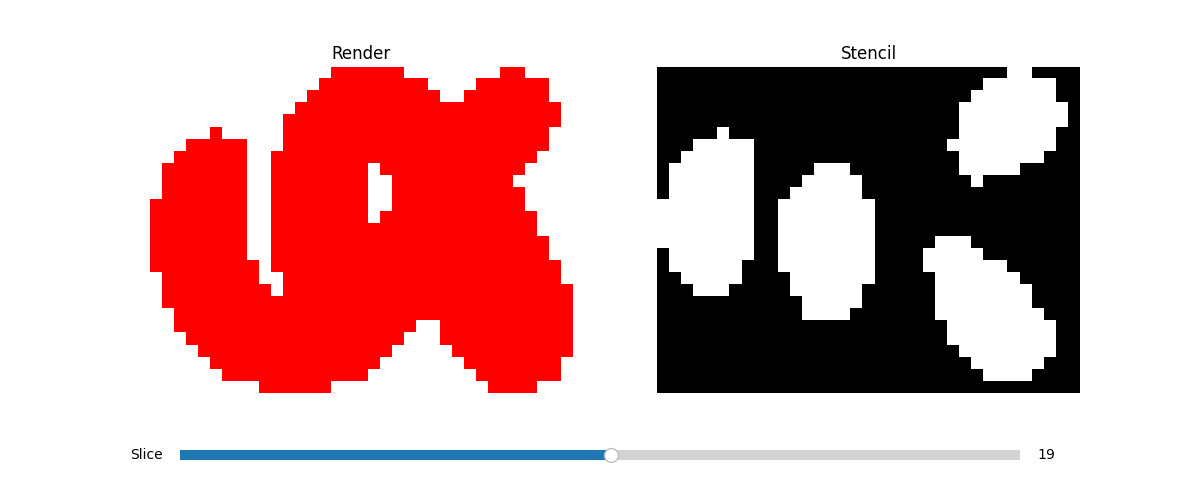

In [30]:
%matplotlib widget

nslices = len(stencil)
start_idx = nslices // 2

fig, (ax_color, ax_stencil) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(bottom=0.2)

color_img = ax_color.imshow(np.flipud(color[start_idx]))
ax_color.set_title(f"Render")
ax_color.axis("off")

stencil_img = ax_stencil.imshow(
    np.flipud(stencil[start_idx]),
    cmap="gray",
    vmin=0,
    vmax=255,
)
ax_stencil.set_title(f"Stencil")
ax_stencil.axis("off")

slider_ax = fig.add_axes((0.15, 0.07, 0.7, 0.04))
slider = Slider(
    ax=slider_ax,
    label="Slice",
    valmin=0,
    valmax=nslices - 1,
    valinit=start_idx,
    valstep=1,
)

tick_positions = np.linspace(0, nslices - 1, num=min(7, nslices), dtype=int)
tick_positions = np.unique(tick_positions)
slider_ax.set_xticks(tick_positions)
slider_ax.set_xticklabels([f"Slice {idx}" for idx in tick_positions])

def update(index: float) -> None:
    idx = int(index)
    color_img.set_data(np.flipud(color[idx]))
    stencil_img.set_data(np.flipud(stencil[idx]))
    ax_color.set_title(f"Render")
    ax_stencil.set_title(f"Stencil")
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

In [31]:
import plotly.graph_objects as go

voxel_grid_zyx = np.stack(stencil, axis=0)
voxel_grid_xyz = np.transpose(voxel_grid_zyx, (2, 1, 0))
voxel_grid = np.where(voxel_grid_xyz != 0, 1, 0).astype(np.uint8)

nx, ny, nz = voxel_grid.shape
X, Y, Z = np.mgrid[0:nx, 0:ny, 0:nz]

fig = go.Figure(
    data=go.Isosurface(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=voxel_grid.flatten(),
        isomin=0.5,
        isomax=1.0,
        surface_count=1,
        colorscale="Viridis",
        caps=dict(x_show=False, y_show=False, z_show=False)
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    )
)

fig.show()